In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('../data/PS2_Dataset.csv')
print(df.shape)
df.head()

(6901, 20)


,Logical quotient rating,hackathons,coding skills rating,public speaking points,self-learning capability?,Extra-courses did,certifications,workshops,reading and writing skills,memory capability score,Interested subjects,interested career area,Type of company want to settle in?,Taken inputs from seniors or elders,Interested Type of Books,Management or Technical,hard/smart worker,worked in teams ever?,Introvert,Suggested Job Role
0,5,0,6,2,yes,no,information security,testing,poor,poor,programming,testing,BPA,no,Series,Management,smart worker,yes,no,Applications Developer
1,7,6,4,3,no,yes,shell programming,testing,excellent,medium,Management,system developer,Cloud Services,yes,Autobiographies,Technical,hard worker,no,yes,Applications Developer
2,2,3,9,1,no,yes,information security,testing,excellent,poor,data engineering,Business process analyst,product development,yes,Travel,Technical,smart worker,no,no,Applications Developer
3,2,6,3,5,no,yes,r programming,database security,excellent,poor,networks,testing,Testing and Maintainance Services,yes,Guide,Management,smart worker,yes,yes,Applications Developer
4,2,0,3,4,yes,no,distro making,game development,excellent,medium,Software Engineering,system developer,BPA,no,Health,Technical,hard worker,yes,no,Applications Developer


In [3]:
def assign_role(row):
    career   = row['interested career area '].strip()
    subject  = row['Interested subjects'].strip()
    cert     = row['certifications'].strip()
    workshop = row['workshops'].strip()
    mgmt     = row['Management or Technical'].strip()
    company  = row['Type of company want to settle in?'].strip()
    coding   = row['coding skills rating']

    if career == 'security' or subject == 'hacking':
        if workshop == 'hacking' or cert == 'information security':
            return 'Systems Security Administrator'
        return 'Network Security Engineer'

    if career == 'testing' or workshop == 'testing':
        return 'Software Quality Assurance (QA) / Testing'

    if career == 'cloud computing' or subject == 'cloud computing':
        if company == 'Web Services' or workshop == 'web technologies':
            return 'Web Developer'
        return 'Network Security Engineer'

    if career == 'Business process analyst' or mgmt == 'Management':
        if subject == 'data engineering' or cert == 'hadoop':
            return 'Database Developer'
        if company in ['SAaS services', 'Sales and Marketing']:
            return 'CRM Technical Developer'
        return 'Technical Support'
    
    if career == 'developer':
        if cert == 'app development' or workshop == 'game development':
            return 'Mobile Applications Developer'
        if cert == 'machine learning' or subject == 'data engineering':
            return 'Applications Developer'        
        if workshop == 'web technologies' or cert == 'full stack':
            return 'Web Developer'
        if coding >= 7:
            return 'Software Engineer'
        return 'Software Developer'

    if career == 'system developer':
        if subject == 'networks' or workshop == 'database security':
            return 'Database Developer'
        if subject == 'IOT':
            return 'CRM Technical Developer'
        if subject == 'Computer Architecture' or workshop == 'system designing':
            return 'Systems Security Administrator'
        if coding >= 7:
            return 'Software Engineer'
        return 'Software Developer'

    if subject == 'programming' and coding >= 7:
        return 'Software Engineer'

    return 'Technical Support'


df['New Job Role'] = df.apply(assign_role, axis=1)
print(" Target rebuilt successfully!")
print("\nNew role distribution:")
print(df['New Job Role'].value_counts())

 Target rebuilt successfully!

New role distribution:
New Job Role
Network Security Engineer                    2264
Software Quality Assurance (QA) / Testing    1520
Technical Support                            1073
Systems Security Administrator                469
Database Developer                            443
Web Developer                                 354
CRM Technical Developer                       271
Software Developer                            234
Software Engineer                             109
Mobile Applications Developer                  93
Applications Developer                         71
Name: count, dtype: int64


In [4]:
df_enc = df.drop('Suggested Job Role', axis=1).copy()
encoders = {}

# Ordinal encoding
ordinal = {
    'reading and writing skills': {'poor': 0, 'medium': 1, 'excellent': 2},
    'memory capability score':    {'poor': 0, 'medium': 1, 'excellent': 2},
}
for col, mapping in ordinal.items():
    df_enc[col] = df_enc[col].map(mapping)
    encoders[col] = mapping

# Label encoding for all string columns
str_cols = [c for c in df_enc.columns
            if str(df_enc[c].dtype) == 'str'
            and c not in ordinal
            and c != 'New Job Role']

for col in str_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str).values)
    encoders[col] = le

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df_enc['New Job Role'].astype(str).values)
encoders['Suggested Job Role'] = le_target
class_names = le_target.classes_

print("Encoding done!")
print("Target classes:", class_names)

Encoding done!
Target classes: ['Applications Developer' 'CRM Technical Developer' 'Database Developer'
 'Mobile Applications Developer' 'Network Security Engineer'
 'Software Developer' 'Software Engineer'
 'Software Quality Assurance (QA) / Testing'
 'Systems Security Administrator' 'Technical Support' 'Web Developer']


In [5]:
X = df_enc.drop('New Job Role', axis=1)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("Split done!")
print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")

Split done!
X_train: (5520, 19)  |  y_train: (5520,)
X_test:  (1381, 19)   |  y_test:  (1381,)


In [6]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':       XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    trained_models[name] = model
    print(f" {name}: {acc*100:.2f}%\n")

print("Final Results")
for name, acc in results.items():
    print(f"  {name}: {acc*100:.2f}%")

Training Decision Tree...
 Decision Tree: 94.13%

Training Random Forest...
 Random Forest: 76.83%

Training XGBoost...
 XGBoost: 99.57%

Final Results
  Decision Tree: 94.13%
  Random Forest: 76.83%
  XGBoost: 99.57%


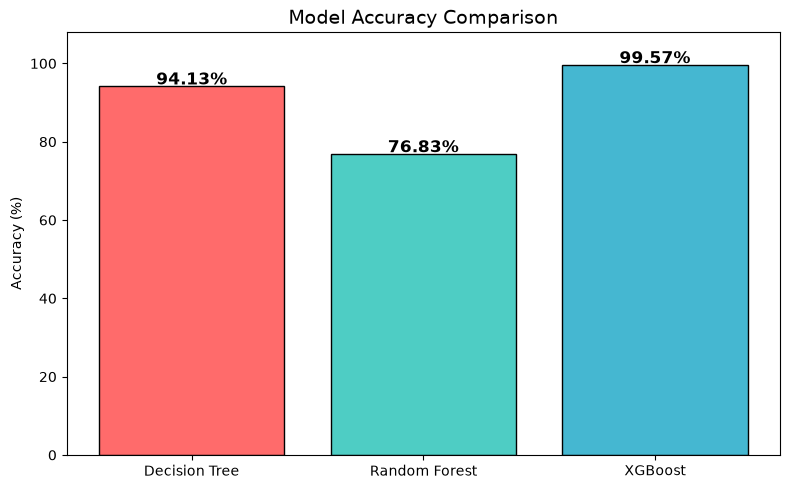

In [7]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), [v*100 for v in results.values()], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')

for bar, val in zip(bars, results.values()):plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 108)
plt.tight_layout()
plt.show()

In [8]:
best_name  = max(results, key=results.get)
best_model = trained_models[best_name]
y_pred     = best_model.predict(X_test)

print(f"Best Model: {best_name} ({results[best_name]*100:.2f}%)\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Best Model: XGBoost (99.57%)

                                           precision    recall  f1-score   support

                   Applications Developer       1.00      1.00      1.00        14
                  CRM Technical Developer       1.00      1.00      1.00        54
                       Database Developer       1.00      1.00      1.00        89
            Mobile Applications Developer       1.00      1.00      1.00        18
                Network Security Engineer       1.00      1.00      1.00       453
                       Software Developer       0.98      1.00      0.99        47
                        Software Engineer       0.91      0.95      0.93        22
Software Quality Assurance (QA) / Testing       1.00      1.00      1.00       304
           Systems Security Administrator       0.99      0.99      0.99        94
                        Technical Support       1.00      1.00      1.00       215
                            Web Developer       1.00    

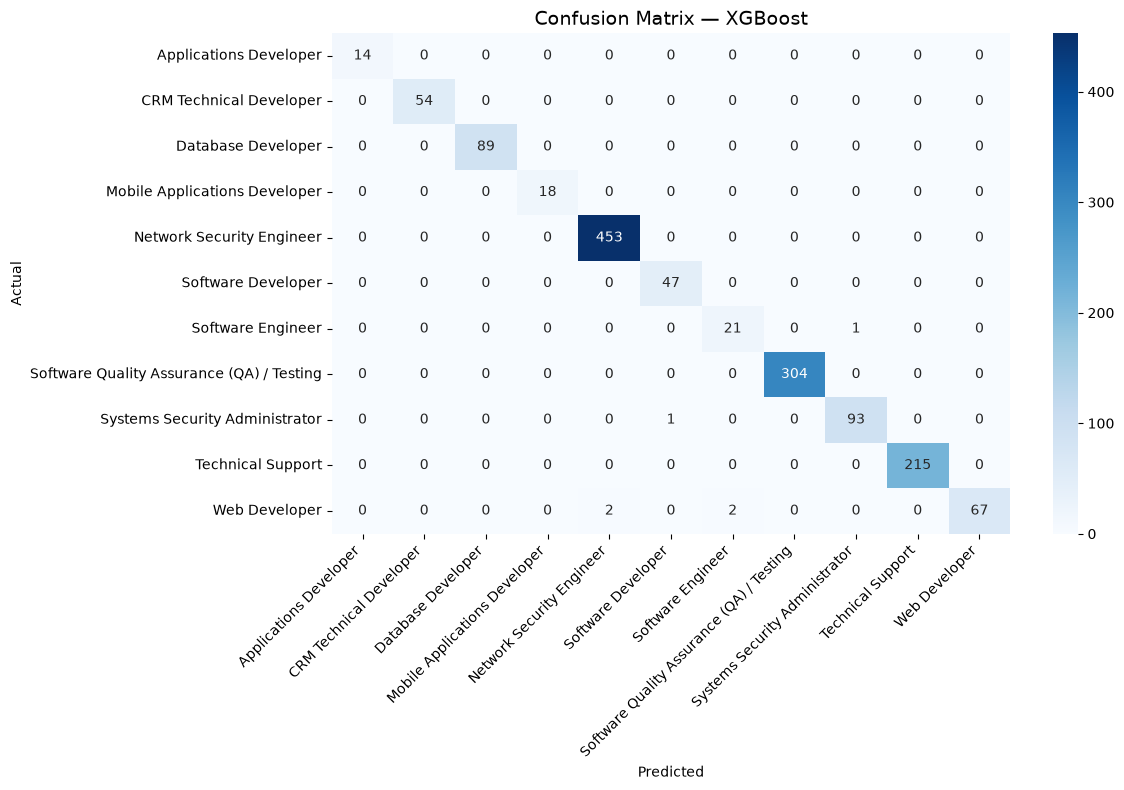

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Siddhi\AppData\Local\Temp\ipykernel_17456\1521657294.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


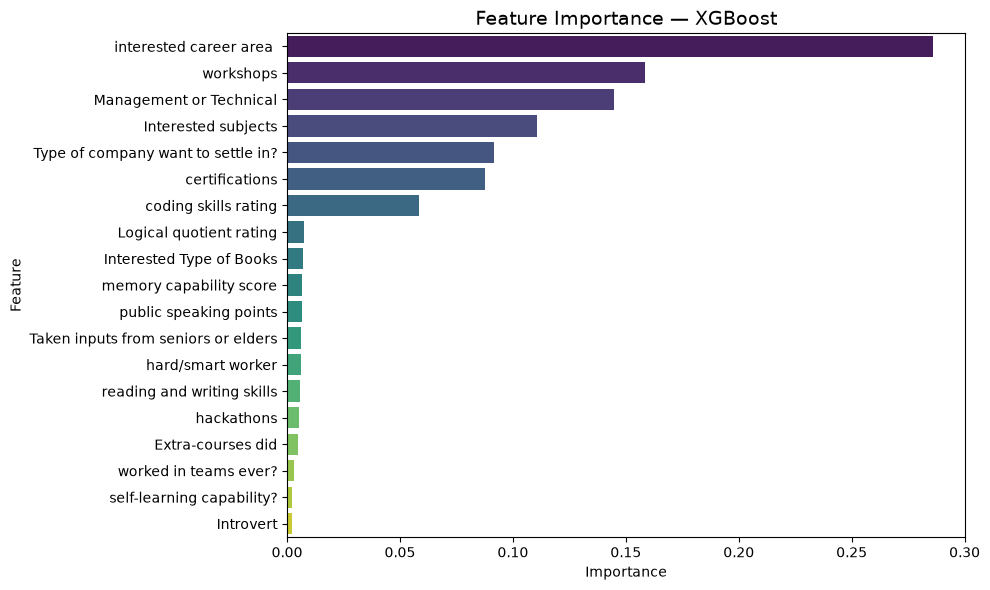


Top 5 most important features:
                               Feature  Importance
11             interested career area     0.286051
7                            workshops    0.158351
15             Management or Technical    0.144606
10                 Interested subjects    0.110549
12  Type of company want to settle in?    0.091827


In [10]:
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Feature Importance — {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_df.head())

In [11]:
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_name)

with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print(f"Best model saved: {best_name}")
print(f"Accuracy: {results[best_name]*100:.2f}%")
print(f"Encoders saved")
print(f"Feature columns saved")
print("\nAll files saved to ../models/ folder!")

Best model saved: XGBoost
Accuracy: 99.57%
Encoders saved
Feature columns saved

All files saved to ../models/ folder!
